<a href="https://colab.research.google.com/github/mori-mkm/UFSCar/blob/main/DESAFIO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORTANDO AS BIBLIOTECAS

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# IMPORTANDO OS DADOS

In [ ]:
df = pd.read_csv("/content/desafio - desafio.csv")
df = df.drop(df.columns[[0]], axis=1)
df.columns = ["x1", "x2", "x3", "y"]
df.head()

,x1,x2,x3,y
0,-1.254599,4.507143,2.319939,-5.249274
1,0.986585,-3.439814,-3.440055,2.752013
2,-4.419164,3.661761,1.011150,-2.176222
3,2.080726,-4.794155,4.699099,2.369752
4,3.324426,-2.876609,-3.181750,0.795191


A base contém 500 observações com quatro variáveis numéricas:

x1, x2, x3 → Variáveis explicativas

y → Variável resposta

# ANALISE DESCRITIVA

In [ ]:
descriptive_stats = df[['x1', 'x2', 'x3', 'y']].describe()
descriptive_stats

,x1,x2,x3,y
count,500.000000,500.000000,500.000000,500.000000
mean,0.176208,-0.135924,-0.059572,0.128614
std,2.836360,2.988853,2.989460,1.902132
min,-4.944779,-4.950600,-4.953680,-5.519663
25%,-2.417834,-2.957984,-2.696848,-0.937088
50%,0.343568,-0.112551,0.018557,0.108345
75%,2.595988,2.445826,2.567203,1.216986
max,4.997177,4.979341,4.911686,7.153553


- **Distribuição Centralizada:**  
  Todas as variáveis possuem média próxima de zero, indicando que os dados são centrados.

- **Dispersão Moderada:**  
  Os desvios padrões das variáveis são relativamente pequenos em comparação aos valores máximos e mínimos, mostrando uma variabilidade controlada.

- **Simetria nas Variáveis:**  
  A comparação entre médias e medianas mostra que as variáveis não apresentam grandes assimetrias (não são altamente enviesadas para a esquerda ou direita).

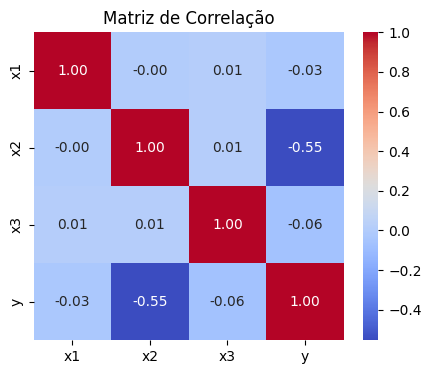

In [ ]:
correlation_matrix = df.corr()

plt.figure(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

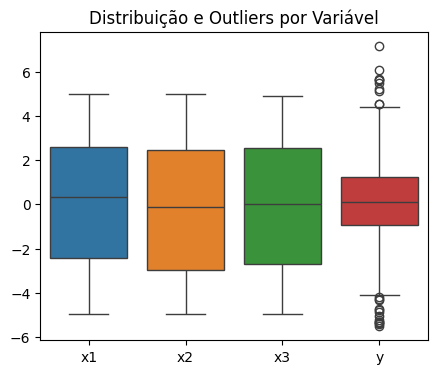

In [ ]:
plt.figure(figsize=(5, 4))
sns.boxplot(data=df[['x1', 'x2', 'x3', 'y']])
plt.title("Distribuição e Outliers por Variável")
plt.show()



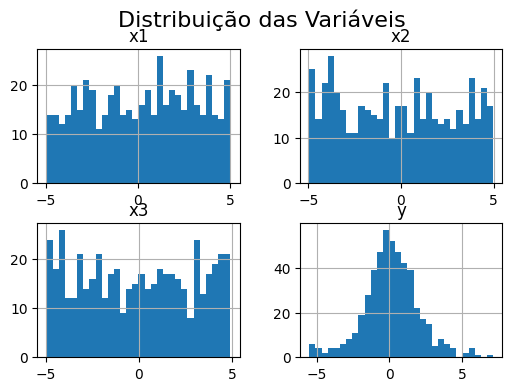

In [ ]:
df[['x1', 'x2', 'x3', 'y']].hist(bins=30, figsize=(6, 4))
plt.suptitle("Distribuição das Variáveis", fontsize=16)
plt.show()

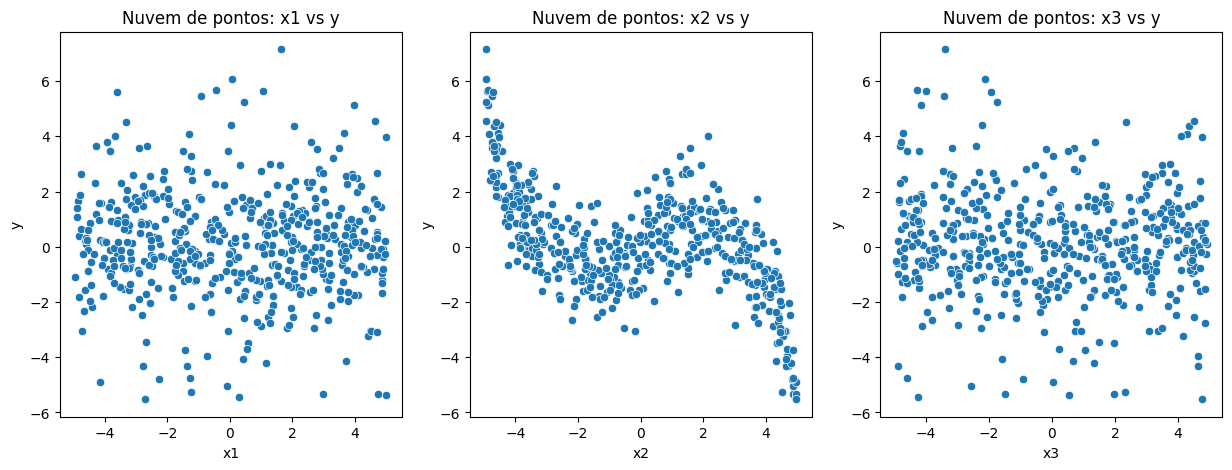

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, var in enumerate(['x1', 'x2', 'x3']):
    sns.scatterplot(data=df, x=var, y='y', ax=axes[i])
    axes[i].set_title(f'Nuvem de pontos: {var} vs y')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('y')
plt.show()


Pelas analises gráficas das variáveis `x1`, `x2` e `x3`, percebemos que elas possuem distribuições aproximadamente simétricas e não apresentam outliers significativos. A variável resposta `y`, apesar de bem distribuída, apresenta alguns outliers.

A matriz de correlação indicou correlações fracas no geral, mas a variável `x2` destacou-se com uma correlação moderada com `y`, sendo uma potencial escolha para modelagem. Essa tendência também foi observada nos gráficos de dispersão, onde apenas `x2` mostrou uma relação cubica com `y`, enquanto `x1` e `x3` não apresentaram relação clara.

Com base nesses resultados, a variável `x2` foi selecionada para as próximas etapas de análise.


# Cross Validation

In [ ]:
X = df[['x2']].values
y = df['y'].values

kf = KFold(n_splits=5, shuffle=True, random_state=4)
mse_results = {}

for grau in range(1, 11):
    mse_folds = []
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        polinomio = PolynomialFeatures(degree=grau, include_bias=True)
        X_train_polinomio = polinomio.fit_transform(X_train)
        X_val_polinomio = polinomio.transform(X_val)

        model = LinearRegression()
        model.fit(X_train_polinomio, y_train)

        y_pred = model.predict(X_val_polinomio)
        mse = mean_squared_error(y_val, y_pred)
        mse_folds.append(mse)


    mse_results[grau] = sum(mse_folds) / len(mse_folds)

mse_results

{1: 2.5113555692436487,
 2: 2.5229289115716944,
 3: 1.0834189002211405,
 4: 1.086191297170421,
 5: 1.0904202947291375,
 6: 1.0884749188028513,
 7: 1.0370625285517476,
 8: 1.0418560518967022,
 9: 1.0471877551525803,
 10: 1.0549219765995925}

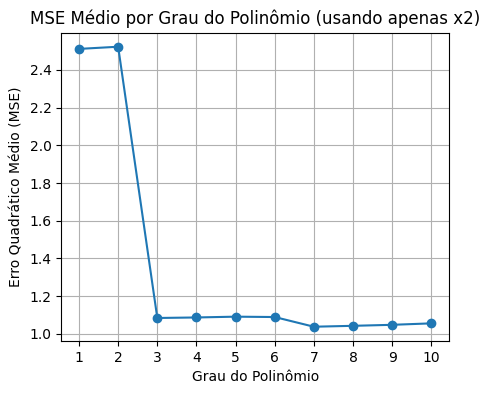

In [ ]:
plt.figure(figsize=(5, 4))
plt.plot(list(mse_results.keys()), list(mse_results.values()), marker='o')
plt.title('MSE Médio por Grau do Polinômio (usando apenas x2)')
plt.xlabel('Grau do Polinômio')
plt.ylabel('Erro Quadrático Médio (MSE)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

Mesmo que o polinômio de grau 7 tenha apresentado a menor média de MSE, não observamos uma diferença tão grande entre a MSE médio do polinômio de grau 3 com o de grau 7.

Além disso, vimos anteriormente que `x2` com `y` apresenta uma relação cubica e para fins de reduzir a complexibilidade do modelo, vamos seguir com o polinômio de grau 3.



# Ajustando o modelo final

In [ ]:
polinomial = PolynomialFeatures(degree=3, include_bias=True)
X_polinomial = polinomial.fit_transform(X)

modelo_sm = sm.OLS(y, X_polinomial).fit()
print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.704
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     393.6
Date:                Thu, 01 May 2025   Prob (F-statistic):          9.68e-131
Time:                        02:41:03   Log-Likelihood:                -725.95
No. Observations:                 500   AIC:                             1460.
Df Residuals:                     496   BIC:                             1477.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0550      0.071      0.770      0.4

- **R² = 0.704:** o modelo explica aproximadamente 70,4% da variação da variável `y`.
- **R² ajustado = 0.702:** ajustado para o número de variáveis, ainda indica bom ajuste.
- **F-statistic (p < 0.001):** o modelo como um todo é estatisticamente significativo.
- **Coeficientes:**
  - `const (intercepto)`: não significativo (p = 0.442).
  - `x1 (x2)`: altamente significativo (p < 0.001), influencia positivamente `y`.
  - `x2 (x2²)`: não significativo (p = 0.922), pouca influência.
  - `x3 (x2³)`: altamente significativo (p < 0.001), influencia negativamente `y`.

In [ ]:
X_polinomial_reduzido = X_polinomial[:, [0, 1, 3]]
modelo_reduzido = sm.OLS(y, X_polinomial_reduzido).fit()
print(modelo_reduzido.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.704
Model:                            OLS   Adj. R-squared:                  0.703
Method:                 Least Squares   F-statistic:                     591.5
Date:                Thu, 01 May 2025   Prob (F-statistic):          3.54e-132
Time:                        02:41:39   Log-Likelihood:                -725.95
No. Observations:                 500   AIC:                             1458.
Df Residuals:                     497   BIC:                             1471.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0603      0.046      1.299      0.1

## Modelo Final (Polinômio de Grau 3, sem o termo x²)

O modelo final ajustado foi:

y = 0,0603 + 0,6439 x2 - 0,0644 x2^3


### Interpretação dos coeficientes:
- **Intercepto (0.0603):** valor esperado de `y` quando `x2 = 0`. Não é estatisticamente significativo (p = 0.195).
- **x2 (0.6439):** coeficiente positivo e significativo (p < 0.001), indicando que `y` tende a aumentar com `x2`, inicialmente.
- **x2³ (-0.0644):** coeficiente negativo e significativo (p < 0.001), indicando uma **curvatura descendente** no comportamento de `y` conforme `x2` aumenta.

O modelo tem **R² = 0.704**, ou seja, explica cerca de **70,4% da variância** da variável resposta `y`, com resíduos normais e sem autocorrelação relevante.


# Análise de resíduos

## Previsão e resíduos

In [ ]:
model_final = LinearRegression()
model_final.fit(X_polinomial_reduzido, y)

y_pred_final = model_final.predict(X_polinomial_reduzido)
residuos = y - y_pred_final


## Testes das suposições dos resíduos


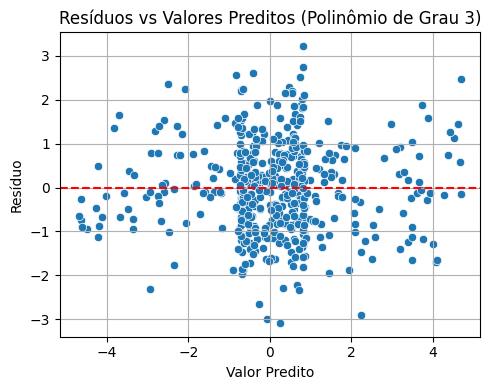

{'Média dos resíduos': np.float64(9.592326932761352e-17),
 'Shapiro-Wilk (p-valor)': np.float64(0.565398914755425),
 'Breusch-Pagan (p-valor)': np.float64(0.29925841789012325)}

In [ ]:
# Média dos resíduos
media_residuos = np.mean(residuos)

# Teste de normalidade (Shapiro-Wilk)
shapiro_stat, shapiro_p = shapiro(residuos)

# Teste de homocedasticidade (Breusch-Pagan)
X_sm_final = sm.add_constant(X_polinomial_reduzido)
bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuos, X_sm_final)

# Gráfico dos resíduos
plt.figure(figsize=(5, 4))
sns.scatterplot(x=y_pred_final, y=residuos)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel('Valor Predito')
plt.ylabel('Resíduo')
plt.title('Resíduos vs Valores Preditos (Polinômio de Grau 3)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Mostrar resultados finais
{
    "Média dos resíduos": media_residuos,
    "Shapiro-Wilk (p-valor)": shapiro_p,
    "Breusch-Pagan (p-valor)": bp_pvalue
}

- **Média dos resíduos:** próxima de zero, indicando ausência de viés sistemático.
- **Teste de normalidade (Shapiro-Wilk):** p-valor = 0.5654 → não rejeitamos a normalidade dos resíduos.
- **Teste de homocedasticidade (Breusch-Pagan):** p-valor = 0.2993 → não há evidência de heterocedasticidade.
- **Gráfico de resíduos:** distribuição aleatória em torno de zero, com um padão evidente, provavelmente o motivo é porque a base de dados deve ser gerada.


**Conclusão:** O modelo polinomial de grau 3 sem o termo \( x^2 \) continua atendendo aos principais pressupostos da regressão linear, mantendo um bom ajuste estatístico e qualidade dos resíduos.